# **🌸 Iris Flower Classification**

This notebook performs a full **data exploration + visualization + statistical analysis** workflow on the classic **Iris dataset**.  
The goal is to understand patterns in flower morphology, compare species, evaluate feature relationships, and prepare the dataset for future machine learning classification tasks.

---

## 🔎 **What This Code Does**

---

## **1️⃣ Loads and Inspects the Dataset**

- Reads the Iris CSV file  
- Displays:
  - First 5 rows  
  - Dataset shape  
  - Column information (data types, non-null counts)  
  - Summary statistics for all numerical columns  
  - Missing values per feature  
- Removes exact duplicate rows (if any)

This gives a complete initial understanding of dataset health.

---

## **2️⃣ Exploratory Data Analysis (EDA)**

The notebook performs a rich set of visual analyses:

### **📌 Class Distribution**
- Countplot of the three species:
  - *Iris-setosa*  
  - *Iris-versicolor*  
  - *Iris-virginica*

### **📌 Feature Relationship Visualizations**
- Scatterplots:
  - SepalLength vs SepalWidth  
  - PetalLength vs PetalWidth  
- Each plot is color-coded by species  
- Legends placed outside the figure for clarity  

### **📌 Pairwise Feature Comparisons**
- A seaborn **pairplot** comparing all features (except Id)  
- Helps identify linearly separable species clusters  
- Highlights how petal dimensions strongly separate classes

### **📌 Individual Feature Distributions**
For each numeric feature:
- SepalLengthCm  
- SepalWidthCm  
- PetalLengthCm  
- PetalWidthCm  

The notebook plots:
- Histograms  
- KDE-based distribution plots  
- Species-wise overlays for pattern comparison

---

## **3️⃣ Statistical Feature Analysis**

### **📌 Feature Correlation (Pearson Method)**

- Computes correlation matrix of all numerical columns  
- Removes unnecessary `Id` column from correlations  
- Visualizes:
  - Annotated heatmap with coolwarm color scheme  
  - Strong relationships such as:
    - PetalLength ↔ PetalWidth  
    - SepalLength ↔ PetalLength  

This forms the analytical backbone for ML feature selection.

---

## **4️⃣ Species-wise Feature Comparison**

Creates boxplots for each feature grouped by species to compare:

- Median differences  
- Variance within species  
- Outlier behavior  
- Distribution separability  

This helps determine which features best distinguish flower classes.

---

## **5️⃣ Outlier Detection & Handling (IQR Method)**

Performs robust outlier analysis on **SepalWidthCm**:

- Calculates:
  - Q1 (25th percentile)  
  - Q3 (75th percentile)  
  - IQR  
- Computes upper & lower bounds  
- Removes outliers safely using boolean masking  
- Displays:
  - Shape before removal  
  - Shape after removal  
  - Side-by-side boxplots (before vs after)

This is essential for preparing clean inputs for future ML classification models.

---

## 🎯 **Final Outcome**

By running this notebook, you will have:

- A fully cleaned and inspected Iris dataset  
- Species-wise visual insights across all features  
- Understanding of the relationships between sepal & petal dimensions  
- Identification of the most discriminative features for ML  
- Outlier-free version of SepalWidthCm  
- Ready foundation for future classification algorithms like:
  - Logistic Regression  
  - KNN  
  - SVM  
  - Decision Trees / Random Forest  
  - Gradient Boosting  


===== HEAD (Top 5 rows) =====
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

===== SHAPE =====
(150, 6)

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtype

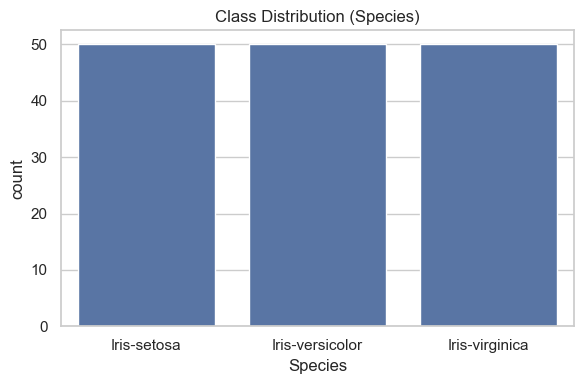

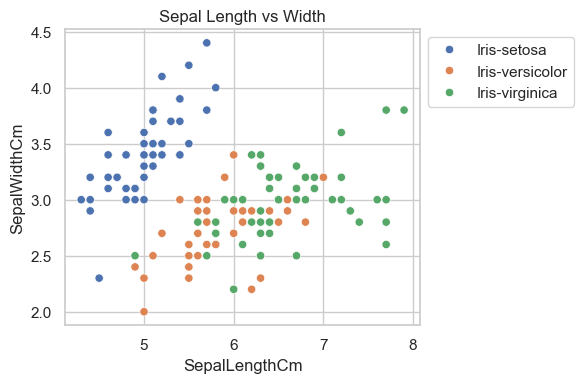

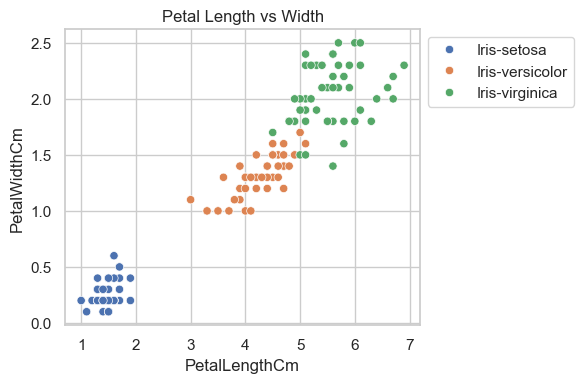

<Figure size 640x480 with 0 Axes>

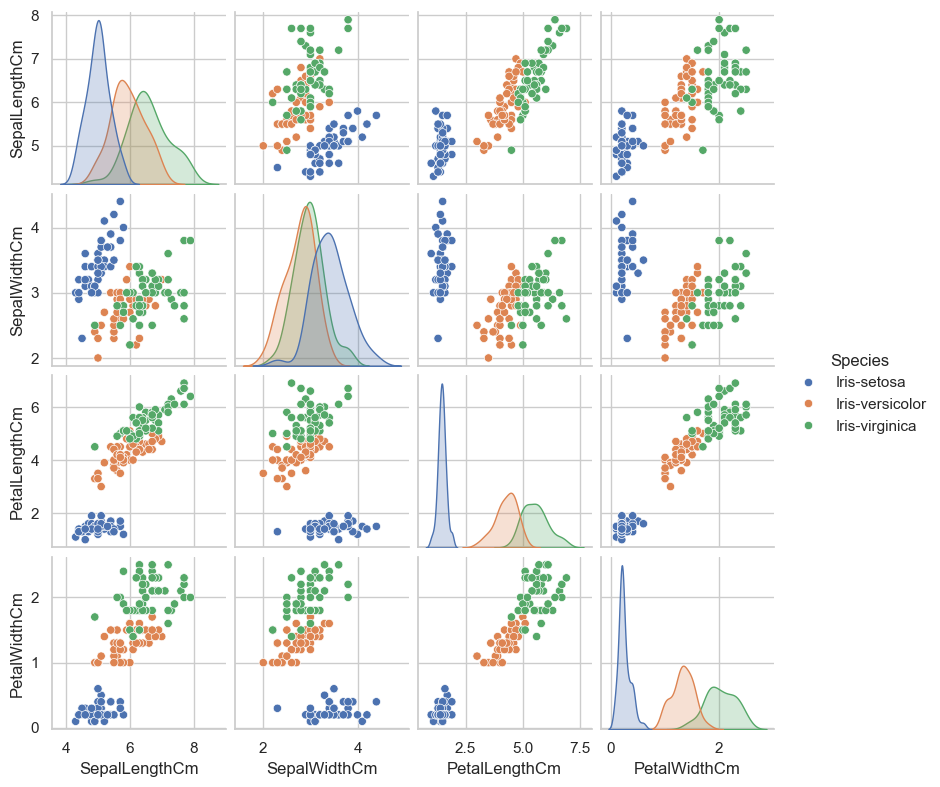

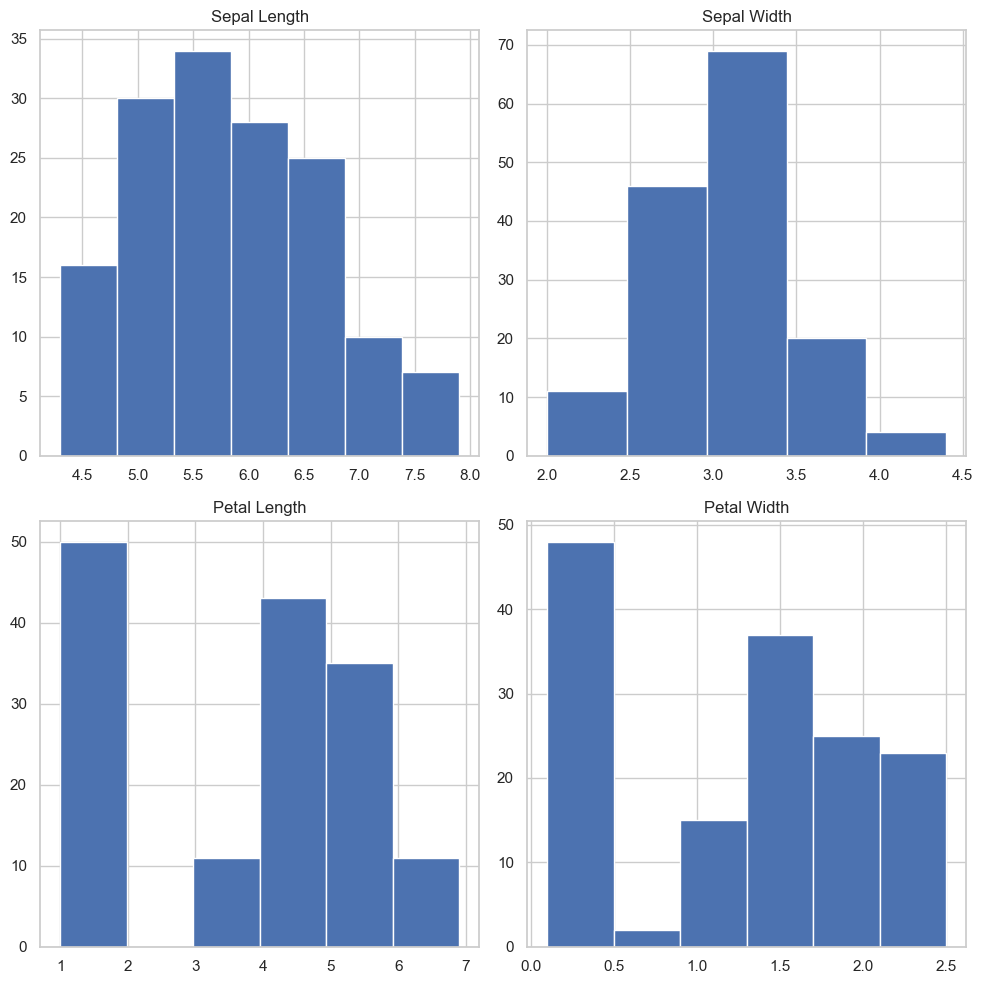

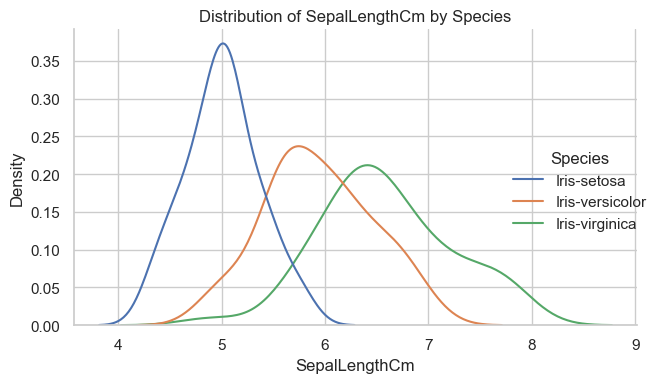

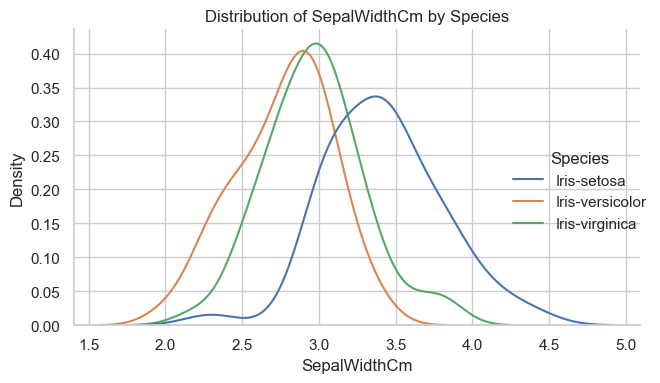

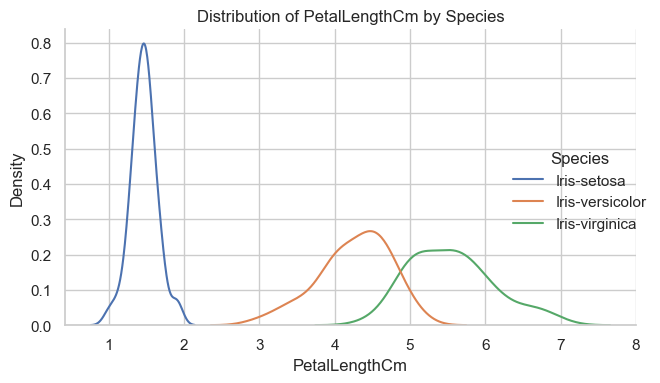

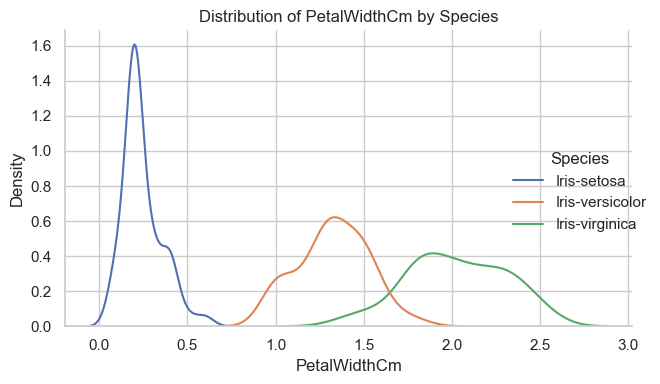


===== CORRELATION MATRIX (NUMERIC FEATURES) =====
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


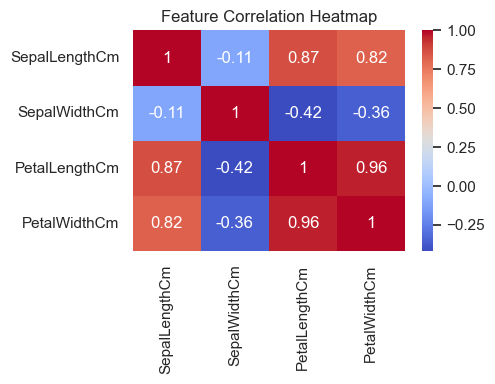

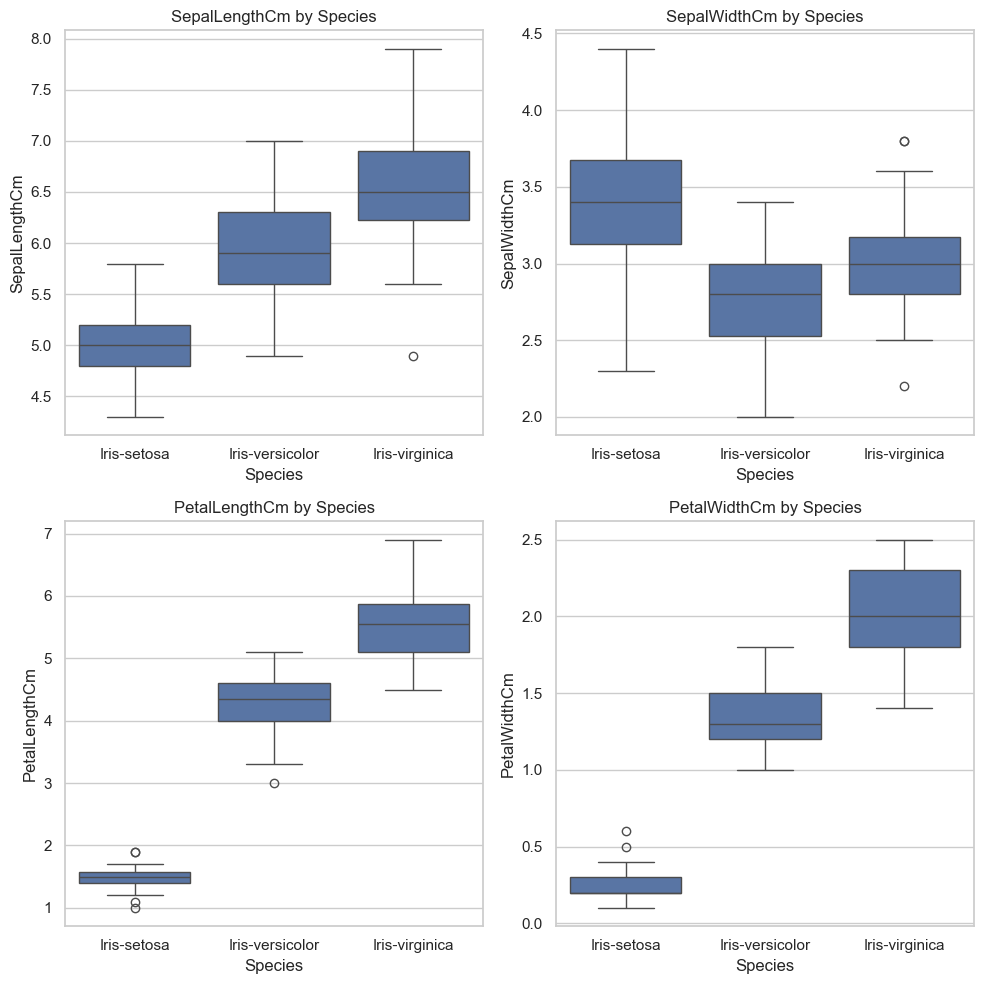


===== OUTLIER ANALYSIS: SepalWidthCm =====
Q1: 2.8
Q3: 3.3
IQR: 0.5
Lower bound: 2.05
Upper bound: 4.05
Old Shape: (150, 6)
New Shape after removing SepalWidthCm outliers: (146, 6)


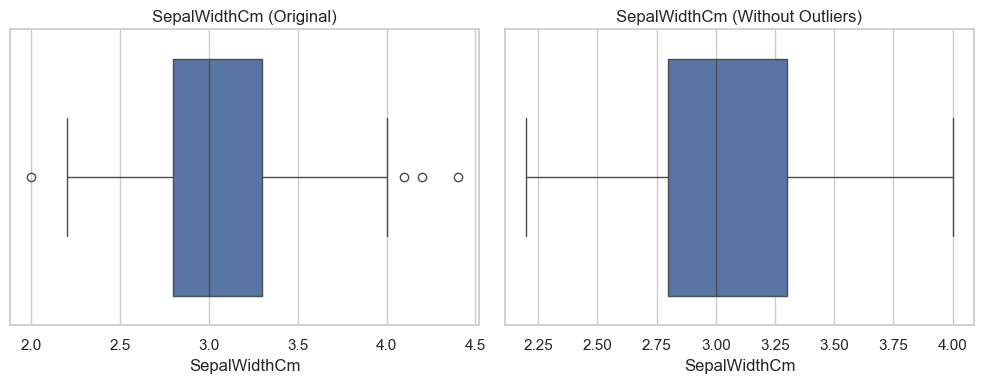

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: nicer default style
sns.set(style="whitegrid")

# ------------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------------

df = pd.read_csv("Iris.csv")

# Basic inspection (works nicely in notebooks; in a .py file use print)
print("\n===== HEAD (Top 5 rows) =====")
print(df.head())

print("\n===== SHAPE =====")
print(df.shape)

print("\n===== INFO =====")
print(df.info())

print("\n===== SUMMARY STATS =====")
print(df.describe())

print("\n===== MISSING VALUES PER COLUMN =====")
print(df.isnull().sum())

# ------------------------------------------------------------------
# 2. Remove duplicate *rows* (not just one row per species)
# ------------------------------------------------------------------

before_dups = df.shape[0]
df = df.drop_duplicates()
after_dups = df.shape[0]
print(f"\nDropped {before_dups - after_dups} duplicate rows. New shape: {df.shape}")

# Class distribution
print("\n===== CLASS COUNTS =====")
print(df["Species"].value_counts())

# ------------------------------------------------------------------
# 3. Visual EDA
# ------------------------------------------------------------------

# a) Countplot of species
plt.figure(figsize=(6, 4))
sns.countplot(x='Species', data=df)
plt.title('Class Distribution (Species)')
plt.tight_layout()
plt.show()

# b) Sepal scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='Species', data=df)
plt.title('Sepal Length vs Width')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

# c) Petal scatterplot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='Species', data=df)
plt.title('Petal Length vs Width')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

# d) Pairplot (remove Id column)
plt.figure()
sns.pairplot(df.drop(['Id'], axis=1), hue='Species', height=2)
plt.show()

# e) Histograms of each numeric feature
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].set_title('Sepal Length')
axes[0, 0].hist(df['SepalLengthCm'], bins=7)

axes[0, 1].set_title('Sepal Width')
axes[0, 1].hist(df['SepalWidthCm'], bins=5)

axes[1, 0].set_title('Petal Length')
axes[1, 0].hist(df['PetalLengthCm'], bins=6)

axes[1, 1].set_title('Petal Width')
axes[1, 1].hist(df['PetalWidthCm'], bins=6)

plt.tight_layout()
plt.show()

# f) Distributions by species (modern replacement for distplot)

numeric_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for col in numeric_cols:
    sns.displot(data=df, x=col, hue='Species', kind='kde', height=4, aspect=1.3)
    plt.title(f'Distribution of {col} by Species')
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------
# 4. Correlation Heatmap (numeric only, excluding Id)
# ------------------------------------------------------------------

num_df = df.select_dtypes(include=['number']).drop(columns=['Id'], errors='ignore')

corr_matrix = num_df.corr(method='pearson')
print("\n===== CORRELATION MATRIX (NUMERIC FEATURES) =====")
print(corr_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 5. Boxplots for each feature per species
# ------------------------------------------------------------------

def boxplot_feature(y_col):
    sns.boxplot(x='Species', y=y_col, data=df)
    plt.title(f'{y_col} by Species')

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
boxplot_feature('SepalLengthCm')

plt.subplot(2, 2, 2)
boxplot_feature('SepalWidthCm')

plt.subplot(2, 2, 3)
boxplot_feature('PetalLengthCm')

plt.subplot(2, 2, 4)
boxplot_feature('PetalWidthCm')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. Outlier detection & removal for SepalWidthCm using IQR
# ------------------------------------------------------------------

# Compute IQR using the modern 'method' argument
Q1 = np.percentile(df['SepalWidthCm'], 25, method='midpoint')
Q3 = np.percentile(df['SepalWidthCm'], 75, method='midpoint')
IQR = Q3 - Q1

print("\n===== OUTLIER ANALYSIS: SepalWidthCm =====")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

old_shape = df.shape

# Boolean mask for non-outliers
mask = (df['SepalWidthCm'] >= lower_bound) & (df['SepalWidthCm'] <= upper_bound)

df_no_outliers = df[mask].copy()

print("Old Shape:", old_shape)
print("New Shape after removing SepalWidthCm outliers:", df_no_outliers.shape)

# Boxplots before & after outlier removal
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(x='SepalWidthCm', data=df)
plt.title('SepalWidthCm (Original)')

plt.subplot(1, 2, 2)
sns.boxplot(x='SepalWidthCm', data=df_no_outliers)
plt.title('SepalWidthCm (Without Outliers)')

plt.tight_layout()
plt.show()
